# Complementarity

This notebook evaluates the complementarity of models by computing the pearson correlation between distances and performances.

Results are explained in Section 4.5.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
from utils import (
    compute_shap_similarity_pearson,
    compute_shap_ndcg_similarity,
    compute_lime_ndcg_similarity,
    compute_lime_similarity_pearson,
    load_nested_results,
)

from sim_global import compute_similarity_pearson, compute_mae_sim

import numpy as np

In [3]:
all_results = load_nested_results("results_all")

In [4]:
dataset_names = list(all_results.keys())
models_names = sorted(list(all_results[dataset_names[0]].keys() - {"ground_truth"}))

In [5]:
import numpy as np
from itertools import combinations
from collections import defaultdict
from sklearn.metrics import average_precision_score
from scipy.stats import rankdata


def aggreg_rank(y_true, y_preds):
    ranks = [rankdata(scores, "average") for scores in y_preds]
    mean_ranks = np.mean(ranks, axis=0)
    return average_precision_score(y_true, mean_ranks)


scores = defaultdict(lambda: defaultdict(list))
n_models_ensemblist = 3

for dataset in dataset_names:
    print(dataset)

    y_true_folds = all_results[dataset]["ground_truth"]

    # Compute similarities on the full set of models first
    dist_shap_sim = 1 - compute_shap_similarity_pearson(all_results[dataset])[0]
    dist_shap_ndcg_sim = 1 - compute_shap_ndcg_similarity(all_results[dataset])[0]

    dist_lime_sim = 1 - compute_lime_similarity_pearson(all_results[dataset])[0]
    dist_lime_ndcg_sim = 1 - compute_lime_ndcg_similarity(all_results[dataset])[0]

    dist_pdp_sim = (
        1 - compute_similarity_pearson(all_results[dataset], "pdp_values", "average")[0]
    )
    dist_pdp_mae = 1 - compute_mae_sim(all_results[dataset], "pdp_values", "average")[0]
    dist_ale_sim = (
        1
        - compute_similarity_pearson(all_results[dataset], "ale_values", "ale_values")[
            0
        ]
    )
    dist_ale_mae = (
        1 - compute_mae_sim(all_results[dataset], "ale_values", "ale_values")[0]
    )

    for comb in combinations(range(len(models_names)), n_models_ensemblist):
        metric = []

        for fold in range(len(y_true_folds)):
            y_true = y_true_folds[fold]

            metric.append(
                aggreg_rank(
                    y_true,
                    np.array(
                        [
                            all_results[dataset][models_names[i]][fold]["scores"]
                            for i in comb
                        ]
                    ),
                )
            )

        dists_shap = []
        dists_shap_ndcg = []

        dists_lime = []
        dists_lime_ndcg = []

        dists_pdp = []
        dists_pdp_mae = []

        dists_ale = []
        dists_ale_mae = []

        # Metric aggregation
        for i in range(n_models_ensemblist):
            for j in range(i + 1, n_models_ensemblist):
                dists_shap.append(dist_shap_sim[comb[i], comb[j]])
                dists_shap_ndcg.append(dist_shap_ndcg_sim[comb[i], comb[j]])

                dists_lime.append(dist_lime_sim[comb[i], comb[j]])
                dists_lime_ndcg.append(dist_lime_ndcg_sim[comb[i], comb[j]])

                dists_pdp.append(dist_pdp_sim[comb[i], comb[j]])
                dists_pdp_mae.append(dist_pdp_mae[comb[i], comb[j]])

                dists_ale.append(dist_ale_sim[comb[i], comb[j]])
                dists_ale_mae.append(dist_ale_mae[comb[i], comb[j]])

        scores[dataset]["name"].append(f"{'-'.join([models_names[i] for i in comb])}")
        scores[dataset]["mcc"].append(np.nanmean(metric))

        scores[dataset]["sh_ndcg"].append(np.mean(dists_shap_ndcg))
        scores[dataset]["shap"].append(np.mean(dists_shap))

        scores[dataset]["lime_ndcg"].append(np.mean(dists_lime_ndcg))
        scores[dataset]["lime"].append(np.mean(dists_lime))

        scores[dataset]["pdp sim"].append(np.mean(dists_pdp))
        scores[dataset]["pdp mae"].append(np.mean(dists_pdp_mae))

        scores[dataset]["ale sim"].append(np.mean(dists_ale))
        scores[dataset]["ale mae"].append(np.mean(dists_ale_mae))

2_annthyroid
4_breastw
14_glass
15_Hepatitis
21_Lymphography
23_mammography
27_PageBlocks
29_Pima
37_Stamps
38_thyroid
39_vertebral
40_vowels
42_WBC
44_Wilt
45_wine
47_yeast


In [6]:
import pandas as pd
from scipy.stats import pearsonr

data = []

for dataset in dataset_names:
    mcc = scores[dataset]["mcc"]

    r_shap_pearson, _ = pearsonr(mcc, scores[dataset]["shap"])
    r_shap_ndcg, _ = pearsonr(mcc, scores[dataset]["sh_ndcg"])

    r_lime_pearson, _ = pearsonr(mcc, scores[dataset]["lime"])
    r_lime_ndcg, _ = pearsonr(mcc, scores[dataset]["lime_ndcg"])

    r_pdp_sim, _ = pearsonr(mcc, scores[dataset]["pdp sim"])
    r_pdp_mae, _ = pearsonr(mcc, scores[dataset]["pdp mae"])

    r_ale_sim, _ = pearsonr(mcc, scores[dataset]["ale sim"])
    r_ale_mae, _ = pearsonr(mcc, scores[dataset]["ale mae"])

    data.append(
        {
            "Dataset": dataset,
            "SHAP PEARSON": r_shap_pearson,
            "SHAP NDCG": r_shap_ndcg,
            "LIME PEARSON": r_lime_pearson,
            "LIME NDCG": r_lime_ndcg,
            "PDP SIM": r_pdp_sim,
            "PDP MAE": r_pdp_mae,
            "ALE SIM": r_ale_sim,
            "ALE MAE": r_ale_mae,
        }
    )

df = pd.DataFrame(data).set_index("Dataset")

df["SHAP PEARSON"] *= 100
df["SHAP NDCG"] *= 100

df["LIME PEARSON"] *= 100
df["LIME NDCG"] *= 100

df["PDP SIM"] *= 100
df["PDP MAE"] *= 100

df["ALE SIM"] *= 100
df["ALE MAE"] *= 100


styled_df = df.style.highlight_max(axis=1, color="red").format(precision=0)

styled_df

,SHAP PEARSON,SHAP NDCG,LIME PEARSON,LIME NDCG,PDP SIM,PDP MAE,ALE SIM,ALE MAE
Dataset,,,,,,,,
2_annthyroid,-18,41,-59,-48,-38,26,16,23
4_breastw,-1,-18,-63,-53,-62,-42,-58,-43
14_glass,11,2,-32,-31,-4,3,11,2
15_Hepatitis,-12,-8,-49,-45,-15,9,-15,9
21_Lymphography,13,-1,-5,-11,-15,-26,-45,-22
23_mammography,-8,-53,-35,-48,-6,-32,-9,-28
27_PageBlocks,-23,18,-24,-11,-18,26,10,30
29_Pima,36,12,-11,-39,29,16,45,16
37_Stamps,37,11,15,11,64,9,16,12


In [7]:
df.mean().round()

SHAP PEARSON     4.0
SHAP NDCG        7.0
LIME PEARSON   -17.0
LIME NDCG      -18.0
PDP SIM         -8.0
PDP MAE          1.0
ALE SIM          4.0
ALE MAE          1.0
dtype: float64

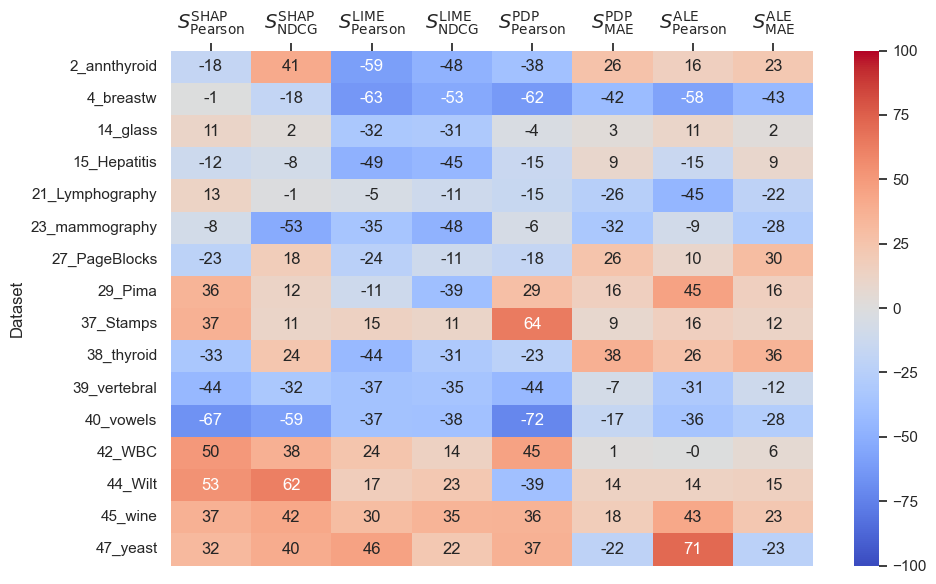

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Maps current column names to the standardized mathematical notation
latex_columns = {
    "SHAP PEARSON": r"$S_{\mathrm{Pearson}}^{\mathrm{SHAP}}$",
    "SHAP NDCG": r"$S_{\mathrm{NDCG}}^{\mathrm{SHAP}}$",
    "LIME PEARSON": r"$S_{\mathrm{Pearson}}^{\mathrm{LIME}}$",
    "LIME NDCG": r"$S_{\mathrm{NDCG}}^{\mathrm{LIME}}$",
    "PDP SIM": r"$S_{\mathrm{Pearson}}^{\mathrm{PDP}}$",
    "PDP MAE": r"$S_{\mathrm{MAE}}^{\mathrm{PDP}}$",
    "ALE SIM": r"$S_{\mathrm{Pearson}}^{\mathrm{ALE}}$",
    "ALE MAE": r"$S_{\mathrm{MAE}}^{\mathrm{ALE}}$",
}


df = df.rename(columns=latex_columns)

fig, ax = plt.subplots(figsize=(10, 6))

sns.set_theme(style="whitegrid", font_scale=1)
sns.heatmap(
    df, annot=True, cmap="coolwarm", center=0, fmt=".0f", ax=ax, vmin=-100, vmax=100
)

ax.xaxis.tick_top()

ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)

# plt.title("Standardized Impact of XAI Diversity on Ensemble Performance", pad=40)


plt.tight_layout()
plt.show()
# fig.savefig("corr_perf_div.eps", format="eps", bbox_inches="tight", pad_inches=0.1)
# plt.close(fig)

<Axes: >

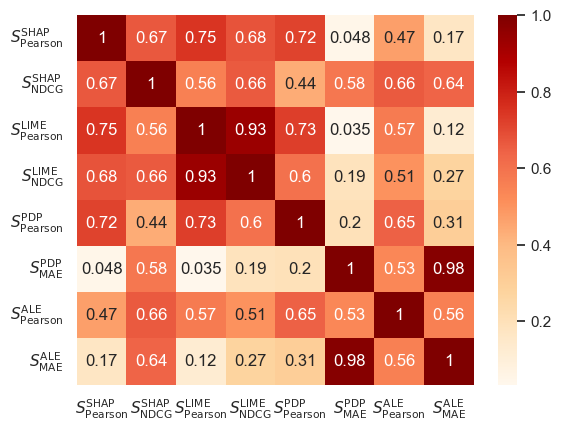

In [9]:
cols = list(df.columns)

nm = len(cols)

m = np.eye(nm)

for i in range(nm):
    for j in range(i, nm):
        m[i, j] = m[j, i] = np.corrcoef(df[cols[i]], df[cols[j]])[0][1]

df_corrs = pd.DataFrame(m, index=cols, columns=cols)
sns.heatmap(df_corrs, annot=True, cmap="OrRd")